# Insurance Anti-Fraud Detection

Predict whether an auto insurance claim is fraudulent (`fraud_reported` = Y/N).

Data: `insurance_claims.csv` from `Eliza516/Insurance-Anti-Fraud-Detection`, commit `7d1b322792ba45878c0f1a879e6aee8328939d34` (originally the Kaggle *Insurance Fraud Claims Detection* set, buntyshah).

Requirements: KNN, Logistic Regression, Naive Bayes, Decision Tree, Random Forest; 80/20 train/test split; decision tree plot; top 5 features; feature selection optional.

Assumptions:
- Binary classification, positive class = fraud (Y).
- Fraud is the minority class (~25%), so the primary metric is **PR-AUC**; ROC-AUC, F1, precision and recall are reported alongside it.
- Each row is a distinct policy (`policy_number` is unique), so no group-aware split is needed.
- Incident dates only span two months (Jan-Mar 2015) — not a forecasting problem — so a stratified random split is used.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from IPython.display import display
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay, classification_report)

SEED = 42
np.random.seed(SEED)
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load data

In [2]:
# keep_default_na=False: 'None' in authorities_contacted is a real category
# ("no authority contacted"), not a missing value.
LOCAL = '../insurance_claims.csv'
URL = 'https://raw.githubusercontent.com/Eliza516/Insurance-Anti-Fraud-Detection/7d1b322792ba45878c0f1a879e6aee8328939d34/insurance_claims.csv'
df_raw = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL, keep_default_na=False, na_values=[''])
print(df_raw.shape)
df_raw.head()

(1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,None,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 2. Quick profiling (observation only, no transforms yet)

In [3]:
profile = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_missing': df_raw.isna().sum(),
    'n_question_mark': (df_raw.astype(str) == '?').sum(),
    'n_unique': df_raw.nunique(),
})
print('Duplicate rows:', df_raw.duplicated().sum())
print('policy_number unique:', df_raw['policy_number'].is_unique)
print('Incident date range:', df_raw['incident_date'].min(), '->', df_raw['incident_date'].max())
profile

Duplicate rows: 0
policy_number unique: True
Incident date range: 2015-01-01 -> 2015-03-01


,dtype,n_missing,n_question_mark,n_unique
months_as_customer,int64,0,0,391
age,int64,0,0,46
policy_number,int64,0,0,1000
policy_bind_date,str,0,0,951
policy_state,str,0,0,3
policy_csl,str,0,0,3
policy_deductable,int64,0,0,3
policy_annual_premium,float64,0,0,991
umbrella_limit,int64,0,0,11
insured_zip,int64,0,0,995


In [4]:
print(df_raw['fraud_reported'].value_counts())
print((df_raw['fraud_reported'].value_counts(normalize=True) * 100).round(1))

fraud_reported
N    753
Y    247
Name: count, dtype: int64
fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64


- 1,000 rows, no duplicates, `policy_number` unique per row. No repeated groups, so a plain random split is fine.
- `_c39` is entirely empty — drop it.
- Missing values are actually coded as `?` in 3 columns: `collision_type` (178), `property_damage` (360), `police_report_available` (343).
- `policy_number`, `incident_location`, `insured_zip` are near-unique identifiers with no general predictive value (and `incident_location`/`insured_zip` are PII) — drop them.
- Label is imbalanced: 75.3% N vs 24.7% Y — split with stratify and use `class_weight`.

## 3. Train / test split (80/20, stratified)

Under 2,000 rows and the assignment calls for an 8/2 split, so **80% train / 20% test** plus **5-fold stratified CV on train** for model/parameter selection. Test is touched only once, at final evaluation.

In [5]:
df = df_raw.copy()
y_all = (df['fraud_reported'] == 'Y').astype(int)
X_all = df.drop(columns=['fraud_reported'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)

split_summary = pd.DataFrame({
    'n_rows': [len(y_train), len(y_test)],
    'share_%': [len(y_train) / len(y_all) * 100, len(y_test) / len(y_all) * 100],
    'fraud_rate_%': [y_train.mean() * 100, y_test.mean() * 100],
}, index=['train', 'test']).round(1)
assert set(X_train_raw['policy_number']).isdisjoint(set(X_test_raw['policy_number']))
print('OK: no overlapping policy_number between train and test')
split_summary

OK: no overlapping policy_number between train and test


,n_rows,share_%,fraud_rate_%
train,800,80.0,24.8
test,200,20.0,24.5


In [6]:
# Compare numeric feature distributions between train and test (KS test)
num_check = ['months_as_customer', 'age', 'policy_annual_premium', 'total_claim_amount',
             'injury_claim', 'property_claim', 'vehicle_claim', 'incident_hour_of_the_day']
ks = pd.DataFrame([(c, *stats.ks_2samp(X_train_raw[c], X_test_raw[c])) for c in num_check],
                  columns=['feature', 'KS_stat', 'p_value']).round(3)
ks

,feature,KS_stat,p_value
0,months_as_customer,0.049,0.831
1,age,0.060,0.600
2,policy_annual_premium,0.080,0.250
3,total_claim_amount,0.094,0.116
4,injury_claim,0.080,0.250
5,property_claim,0.095,0.107
6,vehicle_claim,0.084,0.205
7,incident_hour_of_the_day,0.060,0.600


No p-value below 0.05 — train and test come from the same distribution, as expected from a random split, so adversarial validation isn't needed.

## 4. EDA (on raw train data, before cleaning)

Runs on `X_train_raw` — **before** the cleaning step in section 5 — so the data is seen as-is (`?` still present, date columns as strings, raw `auto_year`...) and observations aren't shaped by cleaning/engineering choices made in advance. Train only, and the label only appears here — test stays untouched.

In [7]:
# ID/PII columns and raw date strings are excluded from categorical analysis — cardinality close to 100%
# gives no generalizable signal (same reasoning as dropping Address/Suburb/SellerG in a housing-price EDA).
ID_DATE_COLS = ['policy_number', 'insured_zip', 'incident_location', 'policy_bind_date', 'incident_date', '_c39']
cat_cols_raw = [c for c in X_train_raw.select_dtypes(exclude='number').columns if c not in ID_DATE_COLS]
num_cols_raw = [c for c in X_train_raw.select_dtypes(include='number').columns if c not in ID_DATE_COLS]
print(len(num_cols_raw), 'numeric columns:', num_cols_raw)
print(len(cat_cols_raw), 'categorical columns:', cat_cols_raw)

eda = X_train_raw.assign(fraud=y_train.values)

16 numeric columns: ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']
17 categorical columns: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


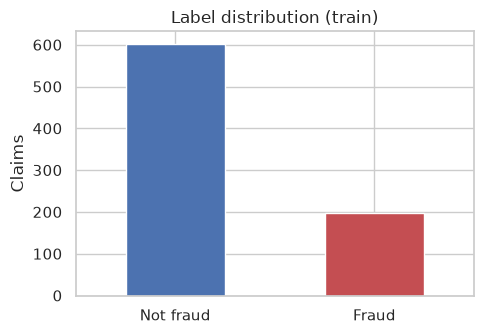

In [8]:
fig, ax = plt.subplots(figsize=(5, 3.5))
eda['fraud'].map({0: 'Not fraud', 1: 'Fraud'}).value_counts().plot.bar(ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Label distribution (train)'); ax.set_ylabel('Claims'); ax.set_xlabel('')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig('figures/01_target.png', dpi=120); plt.show()

About 1 in 4 claims is flagged as fraud, so accuracy alone is misleading — predicting \"not fraud\" for everything already scores ~75%.

In [9]:
# Fraud rate per categorical feature, ranked by spread (max - min) across categories
spread = {}
for c in cat_cols_raw:
    g = eda.groupby(c)['fraud'].agg(['mean', 'size'])
    g = g[g['size'] >= 15]
    spread[c] = g['mean'].max() - g['mean'].min()
spread = pd.Series(spread).sort_values(ascending=False)
spread.round(3).to_frame('fraud_rate_spread')

,fraud_rate_spread
insured_hobbies,0.800
incident_severity,0.518
auto_model,0.492
incident_state,0.339
authorities_contacted,0.235
insured_occupation,0.205
incident_type,0.203
auto_make,0.202
collision_type,0.199
property_damage,0.095


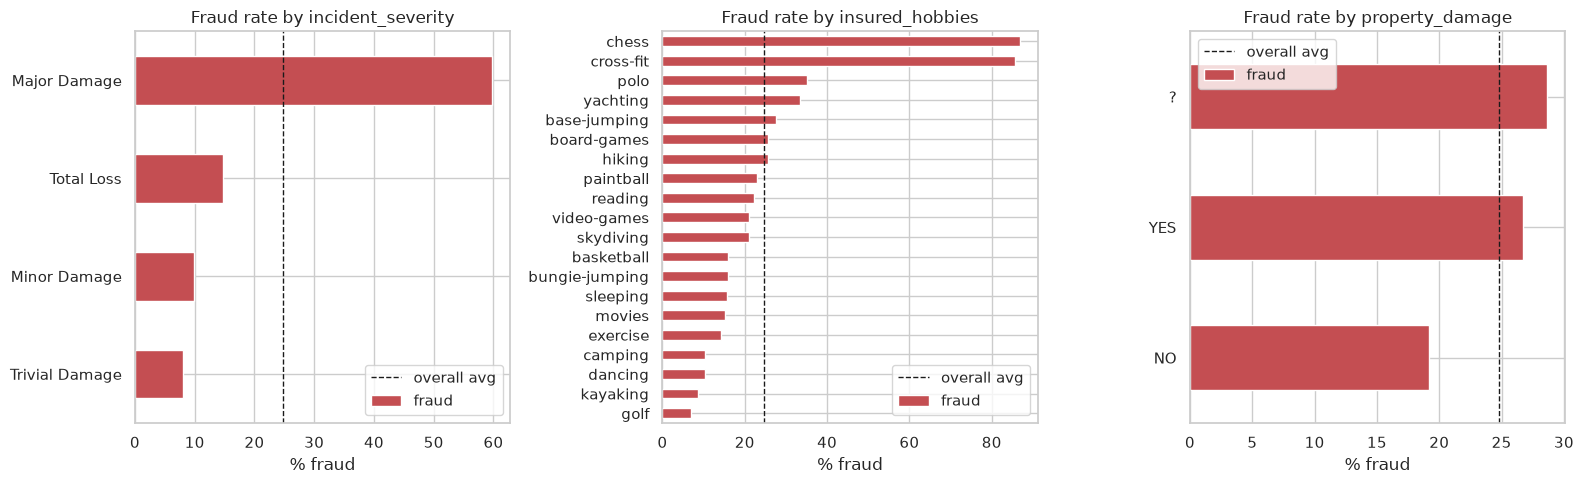

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, c in zip(axes, ['incident_severity', 'insured_hobbies', 'property_damage']):
    r = eda.groupby(c)['fraud'].mean().sort_values() * 100
    r.plot.barh(ax=ax, color='#C44E52')
    ax.axvline(eda['fraud'].mean() * 100, ls='--', c='k', lw=1, label='overall avg')
    ax.set_title(f'Fraud rate by {c}'); ax.set_xlabel('% fraud'); ax.set_ylabel(''); ax.legend()
plt.tight_layout(); plt.savefig('figures/02_fraud_by_category.png', dpi=120); plt.show()

- `incident_severity = Major Damage` has a far higher fraud rate (~60%) than the rest (~10%).
- `chess` and `cross-fit` hobbies show very high fraud rates — a strong signal, but possibly a quirk of this dataset (likely simulated), so it shouldn't be generalized without caution.
- `property_damage` and `police_report_available` show much smaller spread.

In [11]:
# Chi-square test for the two strongest categorical features (train)
rows = []
for c in ['incident_severity', 'insured_hobbies', 'police_report_available', 'insured_sex']:
    ct = pd.crosstab(eda[c], eda['fraud'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    rows.append((c, round(chi2, 1), dof, p, round(cramers_v, 3)))
pd.DataFrame(rows, columns=['feature', 'chi2', 'dof', 'p_value', 'cramers_V'])

,feature,chi2,dof,p_value,cramers_V
0,incident_severity,201.2,3,2.362575e-43,0.501
1,insured_hobbies,171.1,19,1.746357e-26,0.462
2,police_report_available,1.5,2,4.773624e-01,0.043
3,insured_sex,0.0,1,1.000000e+00,0.000


H0: feature independent of fraud label. `incident_severity` and `insured_hobbies` have very small p-values and medium-large Cramér's V — a real association. `police_report_available` and `insured_sex` show no evidence of one. With 4 tests, a Bonferroni correction (α = 0.0125) doesn't change the conclusion.

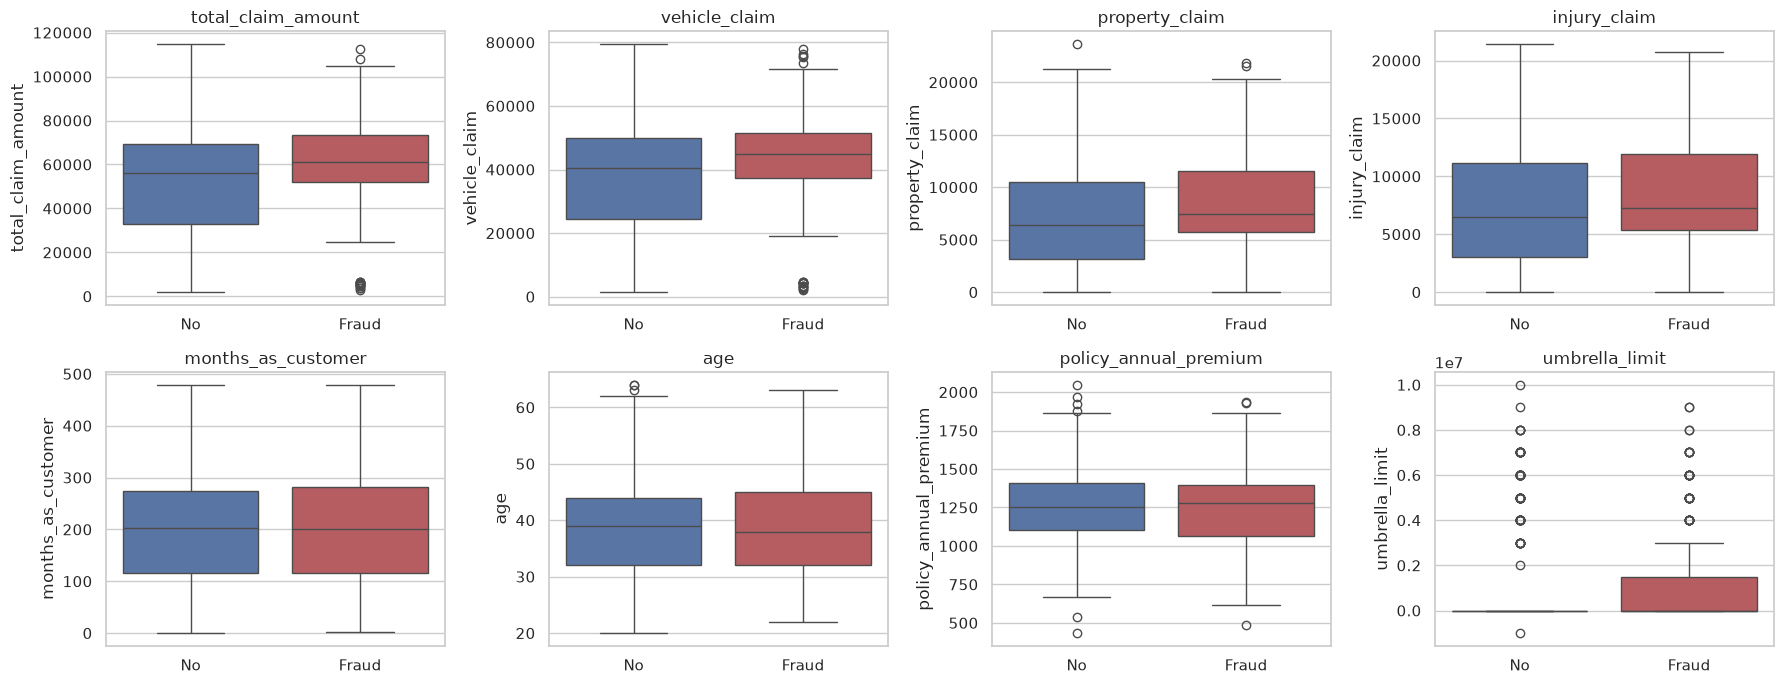

,feature,median_fraud,median_nonfraud,p_mannwhitney
0,total_claim_amount,60995.00,56080.000,0.0000
1,vehicle_claim,44800.00,40560.000,0.0000
2,property_claim,7430.00,6440.000,0.0001
3,injury_claim,7225.00,6505.000,0.0087
4,months_as_customer,200.50,203.000,0.6382
5,age,38.00,39.000,0.9018
6,policy_annual_premium,1276.32,1255.515,0.9422
7,umbrella_limit,0.00,0.000,0.0384


In [12]:
num_eda = ['total_claim_amount', 'vehicle_claim', 'property_claim', 'injury_claim',
           'months_as_customer', 'age', 'policy_annual_premium', 'umbrella_limit']
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), num_eda):
    sns.boxplot(data=eda, x='fraud', y=c, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_xticklabels(['No', 'Fraud']); ax.set_xlabel(''); ax.set_title(c)
plt.tight_layout(); plt.savefig('figures/03_numeric_boxplots.png', dpi=120); plt.show()

mw = pd.DataFrame([(c, eda.loc[eda.fraud == 1, c].median(), eda.loc[eda.fraud == 0, c].median(),
                    stats.mannwhitneyu(eda.loc[eda.fraud == 1, c], eda.loc[eda.fraud == 0, c]).pvalue)
                   for c in num_eda], columns=['feature', 'median_fraud', 'median_nonfraud', 'p_mannwhitney'])
mw.round(4)

Fraudulent claims skew toward higher total claim amounts (mostly `vehicle_claim` and `property_claim`). Demographic and policy variables (age, tenure, premium) barely differ.

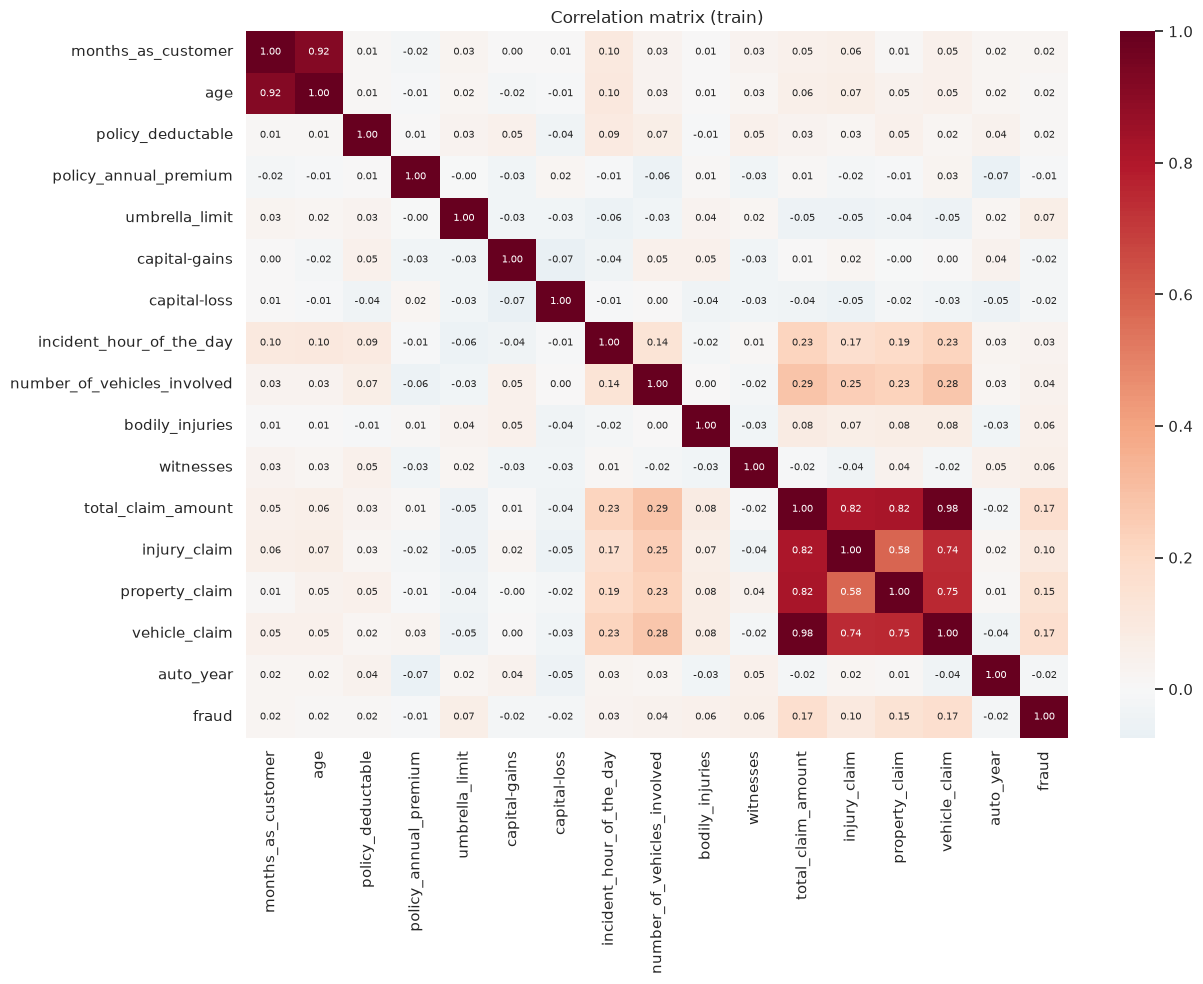

In [13]:
corr = eda[num_cols_raw + ['fraud']].corr()
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation matrix (train)')
plt.tight_layout(); plt.savefig('figures/04_corr.png', dpi=120); plt.show()

- `age` and `months_as_customer` are highly correlated (~0.92).
- `total_claim_amount` is roughly the sum of the three claim types, so it correlates with each of them.
- Multicollinearity hurts Logistic Regression coefficient interpretation but barely affects predictive power. Feature selection and regularization help.
- Linear correlation between numeric features and the label is weak everywhere (< 0.2) — the signal lives mostly in categorical features.

## 5. Cleaning (deterministic rules, nothing learned from data)

Every step below is a fixed transform (no fitted parameters), so it's applied identically to train and test:
- Drop the empty `_c39` column and identifier/PII columns (`policy_number`, `insured_zip`, `incident_location`).
- Replace `?` with an explicit `'Unknown'` category — missingness itself (e.g. no police report on file) can be a signal, so it's kept as a category rather than imputed.
- From the two date columns, derive `policy_age_days` (days between policy start and incident) and `incident_weekday`, then drop the raw dates.
- Derive claim-share features `injury_share`, `property_share`, `vehicle_share` (each type's fraction of the total claim).
- Replace `auto_year` with `vehicle_age` = 2015 − manufacture year.

These choices follow directly from section 4: `?` carries signal (kept as a category rather than imputed), `incident_severity`/`insured_hobbies` are the two strongest categorical features, and the date/`auto_year` columns need to become meaningful features (`policy_age_days`, `incident_weekday`, `vehicle_age`) before modeling.

In [14]:
DROP_COLS = ['_c39', 'policy_number', 'insured_zip', 'incident_location']

def clean(X: pd.DataFrame) -> pd.DataFrame:
    X = X.drop(columns=DROP_COLS).copy()
    X = X.replace('?', 'Unknown')
    bind = pd.to_datetime(X.pop('policy_bind_date'))
    inc = pd.to_datetime(X.pop('incident_date'))
    X['policy_age_days'] = (inc - bind).dt.days
    X['incident_weekday'] = inc.dt.day_name()
    total = X['total_claim_amount'].replace(0, np.nan)
    for c in ['injury', 'property', 'vehicle']:
        X[f'{c}_share'] = (X[f'{c}_claim'] / total).fillna(0)
    X['vehicle_age'] = 2015 - X.pop('auto_year')
    return X

X_train = clean(X_train_raw)
X_test = clean(X_test_raw)
print('train:', X_train_raw.shape, '->', X_train.shape, '| test:', X_test_raw.shape, '->', X_test.shape)

cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print(len(num_cols), 'numeric columns:', num_cols)
print(len(cat_cols), 'categorical columns:', cat_cols)

train: (800, 39) -> (800, 38) | test: (200, 39) -> (200, 38)
20 numeric columns: ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'policy_age_days', 'injury_share', 'property_share', 'vehicle_share', 'vehicle_age']
18 categorical columns: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'incident_weekday']


## 6. Feature engineering & pipeline

- Preprocessing: `StandardScaler` for numeric features, `OneHotEncoder(handle_unknown='ignore')` for categorical.
- Feature selection: `SelectKBest(f_classif)`, with `k` tuned via CV.
- Everything lives inside a `Pipeline`, so every `fit` only ever sees the train fold — no leakage.

In [15]:
def make_pipe(model, select=True, scale=True):
    # Tree models don't need scaling -> keep original units (USD, months...) for readable thresholds
    pre = ColumnTransformer([
        ('num', StandardScaler() if scale else 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])
    steps = [('pre', pre)]
    if select:
        steps.append(('select', SelectKBest(f_classif)))
    steps.append(('model', model))
    return Pipeline(steps)

n_ohe = make_pipe(DummyClassifier(), select=False).named_steps['pre'].fit(X_train).transform(X_train).shape[1]
print('Features after one-hot:', n_ohe)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {'pr_auc': 'average_precision', 'roc_auc': 'roc_auc', 'f1': 'f1'}
K_GRID = [5, 10, 20, 40, 'all']

Features after one-hot: 172


## 7. Baseline -> 5 models -> tuning via GridSearchCV (5-fold stratified)

In [16]:
search_spaces = {
    'Dummy (baseline)': (make_pipe(DummyClassifier(strategy='stratified', random_state=SEED), select=False), {}),
    'Logistic Regression': (make_pipe(LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=SEED)),
                            {'select__k': K_GRID, 'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l1', 'l2']}),
    'KNN': (make_pipe(KNeighborsClassifier()),
            {'select__k': K_GRID, 'model__n_neighbors': [5, 11, 21, 31], 'model__weights': ['uniform', 'distance']}),
    'Naive Bayes': (make_pipe(GaussianNB()),
                    {'select__k': K_GRID, 'model__var_smoothing': [1e-9, 1e-6, 1e-3, 1e-1]}),
    'Decision Tree': (make_pipe(DecisionTreeClassifier(class_weight='balanced', random_state=SEED), scale=False),
                      {'select__k': K_GRID, 'model__max_depth': [2, 3, 4, 5, 8],
                       'model__min_samples_leaf': [1, 10, 20]}),
    'Random Forest': (make_pipe(RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEED), scale=False),
                      {'select__k': [10, 20, 40, 'all'], 'model__max_depth': [4, 8, None],
                       'model__min_samples_leaf': [1, 5], 'model__max_features': ['sqrt', 0.3]}),
}

searches, rows = {}, []
for name, (pipe, grid) in search_spaces.items():
    gs = GridSearchCV(pipe, grid, scoring=SCORING, refit='pr_auc', cv=cv, n_jobs=-1, return_train_score=True)
    gs.fit(X_train, y_train)
    searches[name] = gs
    r = gs.cv_results_; i = gs.best_index_
    rows.append({
        'model': name,
        'CV PR-AUC': f"{r['mean_test_pr_auc'][i]:.3f} ± {r['std_test_pr_auc'][i]:.3f}",
        'CV ROC-AUC': f"{r['mean_test_roc_auc'][i]:.3f} ± {r['std_test_roc_auc'][i]:.3f}",
        'CV F1': f"{r['mean_test_f1'][i]:.3f} ± {r['std_test_f1'][i]:.3f}",
        'train PR-AUC': round(r['mean_train_pr_auc'][i], 3),
        'cv_pr_auc_mean': r['mean_test_pr_auc'][i],
        'best_params': {k.split('__')[1]: v for k, v in gs.best_params_.items()},
    })
cv_table = pd.DataFrame(rows).sort_values('cv_pr_auc_mean', ascending=False).reset_index(drop=True)
cv_table.drop(columns='cv_pr_auc_mean')

,model,CV PR-AUC,CV ROC-AUC,CV F1,train PR-AUC,best_params
0,Naive Bayes,0.726 ± 0.022,0.888 ± 0.016,0.744 ± 0.022,0.726,"{'var_smoothing': 0.001, 'k': 10}"
1,Decision Tree,0.712 ± 0.056,0.885 ± 0.028,0.756 ± 0.032,0.792,"{'max_depth': 5, 'min_samples_leaf': 10, 'k': 10}"
2,Logistic Regression,0.707 ± 0.031,0.876 ± 0.034,0.756 ± 0.032,0.708,"{'C': 10, 'penalty': 'l2', 'k': 5}"
3,Random Forest,0.639 ± 0.060,0.867 ± 0.028,0.745 ± 0.031,0.966,"{'max_depth': 8, 'max_features': 'sqrt', 'min_..."
4,KNN,0.628 ± 0.052,0.860 ± 0.034,0.671 ± 0.067,0.755,"{'n_neighbors': 5, 'weights': 'uniform', 'k': 5}"
5,Dummy (baseline),0.262 ± 0.046,0.500 ± 0.079,0.253 ± 0.119,0.253,{}


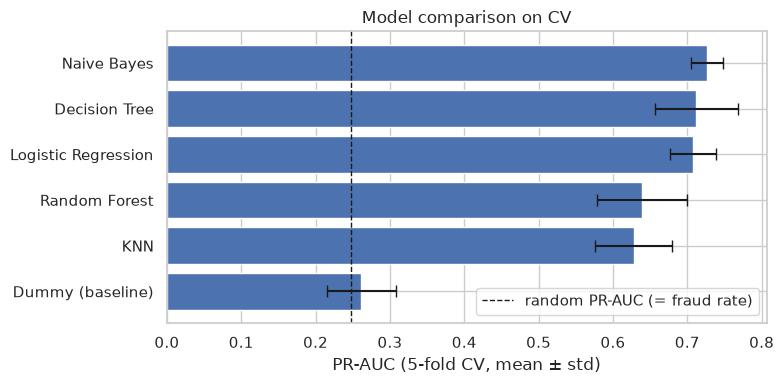

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
means = [searches[m].cv_results_['mean_test_pr_auc'][searches[m].best_index_] for m in cv_table['model']]
stds = [searches[m].cv_results_['std_test_pr_auc'][searches[m].best_index_] for m in cv_table['model']]
ax.barh(cv_table['model'][::-1], means[::-1], xerr=stds[::-1], color='#4C72B0', capsize=4)
ax.axvline(y_train.mean(), ls='--', c='k', lw=1, label='random PR-AUC (= fraud rate)')
ax.set_xlabel('PR-AUC (5-fold CV, mean ± std)'); ax.set_title('Model comparison on CV'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('figures/05_cv_comparison.png', dpi=120); plt.show()

Table and chart show the spread across models. A gap between train PR-AUC and CV PR-AUC signals overfitting (see the learning curve below).

In [18]:
# Effect of feature selection: best CV score per k (Logistic Regression & Decision Tree)
rows = []
for name in ['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'KNN']:
    res = pd.DataFrame(searches[name].cv_results_)
    res['k'] = res['param_select__k'].astype(str)
    best_by_k = res.groupby('k')['mean_test_pr_auc'].max()
    for k, v in best_by_k.items():
        rows.append((name, k, v))
fs = pd.DataFrame(rows, columns=['model', 'k', 'best_cv_pr_auc']).pivot(index='k', columns='model', values='best_cv_pr_auc')
fs = fs.loc[[str(k) for k in K_GRID]]
fs.round(3)

model,Decision Tree,KNN,Logistic Regression,Naive Bayes
k,,,,
5,0.705,0.628,0.707,0.718
10,0.712,0.581,0.707,0.726
20,0.705,0.570,0.686,0.650
40,0.681,0.523,0.673,0.613
all,0.685,0.409,0.694,0.610


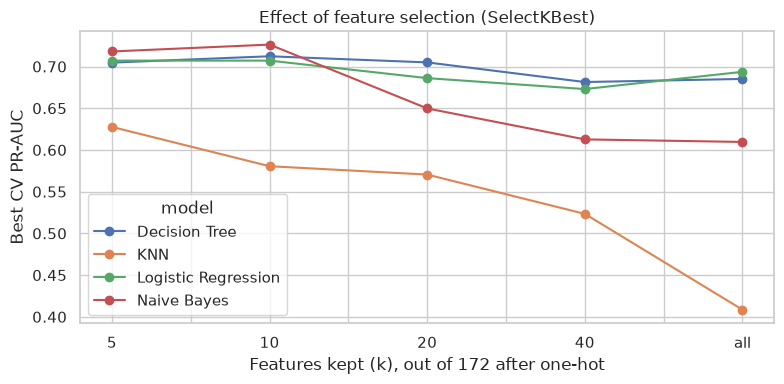

In [19]:
ax = fs.plot(marker='o', figsize=(8, 4))
ax.set_xlabel(f'Features kept (k), out of {n_ohe} after one-hot'); ax.set_ylabel('Best CV PR-AUC')
ax.set_title('Effect of feature selection (SelectKBest)')
plt.tight_layout(); plt.savefig('figures/06_feature_selection.png', dpi=120); plt.show()

For most models, keeping only a handful of features (5-20) matches or beats using all of them — most features are noise, and dimensionality reduction helps KNN/Naive Bayes noticeably.

### 7.1 Final model & decision threshold

Final model picked by highest CV PR-AUC. The probability threshold is chosen from **out-of-fold predictions on train** (maximizing F1) — test is never touched here.

In [20]:
best_name = cv_table.loc[0, 'model']
final_model = searches[best_name].best_estimator_
print('Final model:', best_name, searches[best_name].best_params_)

oof = cross_val_predict(final_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = float(thr[np.argmax(f1s)])
print(f'F1-optimal threshold (OOF train): {best_thr:.3f} | F1 OOF = {f1s.max():.3f} | F1 OOF at 0.5 = {f1_score(y_train, oof >= 0.5):.3f}')

Final model: Naive Bayes {'model__var_smoothing': 0.001, 'select__k': 10}
F1-optimal threshold (OOF train): 0.372 | F1 OOF = 0.755 | F1 OOF at 0.5 = 0.743


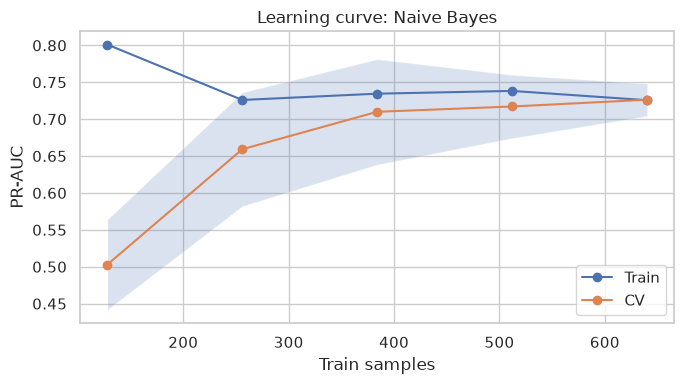

In [21]:
sizes, tr, va = learning_curve(final_model, X_train, y_train, cv=cv, scoring='average_precision',
                               train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, tr.mean(1), 'o-', label='Train'); ax.plot(sizes, va.mean(1), 'o-', label='CV')
ax.fill_between(sizes, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=0.2)
ax.set_xlabel('Train samples'); ax.set_ylabel('PR-AUC'); ax.set_title(f'Learning curve: {best_name}'); ax.legend()
plt.tight_layout(); plt.savefig('figures/07_learning_curve.png', dpi=120); plt.show()

The gap between the two curves indicates overfit. If the CV curve is still climbing, more data would help.

## 8. Final evaluation on test (one pass, final model only)

In [22]:
def evaluate(y, p, thr):
    pred = (p >= thr).astype(int)
    return {'PR-AUC': average_precision_score(y, p), 'ROC-AUC': roc_auc_score(y, p),
            'F1': f1_score(y, pred), 'Precision': precision_score(y, pred, zero_division=0),
            'Recall': recall_score(y, pred), 'Accuracy': accuracy_score(y, pred)}

p_test = final_model.predict_proba(X_test)[:, 1]
p_base = searches['Dummy (baseline)'].best_estimator_.predict_proba(X_test)[:, 1]
final_eval = pd.DataFrame({
    f'{best_name} (threshold {best_thr:.2f})': evaluate(y_test, p_test, best_thr),
    f'{best_name} (threshold 0.50)': evaluate(y_test, p_test, 0.5),
    'Dummy baseline': evaluate(y_test, p_base, 0.5),
}).T.round(3)
final_eval

,PR-AUC,ROC-AUC,F1,Precision,Recall,Accuracy
Naive Bayes (threshold 0.37),0.551,0.837,0.730,0.636,0.857,0.845
Naive Bayes (threshold 0.50),0.551,0.837,0.737,0.646,0.857,0.850
Dummy baseline,0.260,0.534,0.300,0.294,0.306,0.650


In [23]:
cv_best = searches[best_name].cv_results_['mean_test_pr_auc'][searches[best_name].best_index_]
print(f'PR-AUC: CV = {cv_best:.3f} | Test = {average_precision_score(y_test, p_test):.3f} | gap = {average_precision_score(y_test, p_test) - cv_best:+.3f}')
print(classification_report(y_test, (p_test >= best_thr).astype(int), target_names=['Not fraud', 'Fraud']))

PR-AUC: CV = 0.726 | Test = 0.551 | gap = -0.176
              precision    recall  f1-score   support

   Not fraud       0.95      0.84      0.89       151
       Fraud       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200



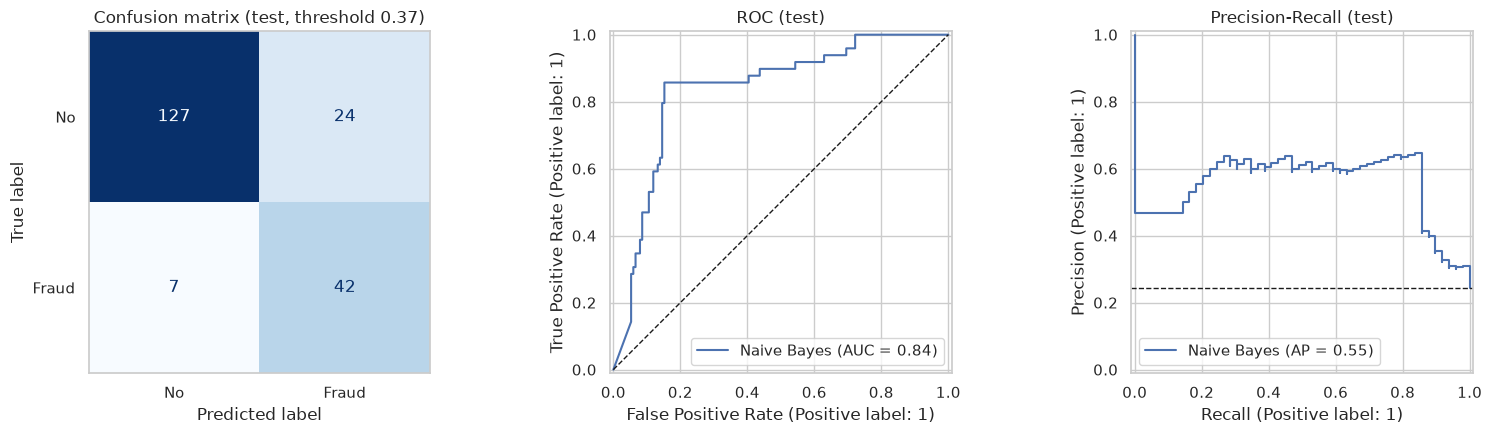

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, (p_test >= best_thr).astype(int)),
                       display_labels=['No', 'Fraud']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion matrix (test, threshold {best_thr:.2f})'); axes[0].grid(False)
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[1], name=best_name)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1); axes[1].set_title('ROC (test)')
PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[2], name=best_name)
axes[2].axhline(y_test.mean(), ls='--', c='k', lw=1); axes[2].set_title('Precision-Recall (test)')
plt.tight_layout(); plt.savefig('figures/08_test_eval.png', dpi=120); plt.show()

### 8.0 Test-score uncertainty & comparison against a simple rule

Test PR-AUC sits notably below CV. Test has only 49 fraud cases, so uncertainty needs quantifying:
- Bootstrap 95% CI for the test score.
- Repeated CV (5x5) on train, to see how much PR-AUC varies across splits.

In [25]:
rng = np.random.default_rng(SEED); boot = {'PR-AUC': [], 'F1': []}
yt = y_test.values; pred_t = (p_test >= best_thr).astype(int)
for _ in range(2000):
    i = rng.integers(0, len(yt), len(yt))
    if yt[i].sum() == 0: continue
    boot['PR-AUC'].append(average_precision_score(yt[i], p_test[i]))
    boot['F1'].append(f1_score(yt[i], pred_t[i]))
ci = {k: np.percentile(v, [2.5, 97.5]).round(3) for k, v in boot.items()}
print('Bootstrap 95% CI on test:', ci)

from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
rep = cross_val_score(final_model, X_train, y_train, scoring='average_precision', n_jobs=-1,
                      cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED))
print(f'Repeated CV 5x5 PR-AUC: {rep.mean():.3f} ± {rep.std():.3f} (min {rep.min():.3f}, max {rep.max():.3f})')
print(f'F1: OOF train = {f1s.max():.3f} | test = {f1_score(y_test, pred_t):.3f}')

Bootstrap 95% CI on test: {'PR-AUC': array([0.427, 0.699]), 'F1': array([0.633, 0.811])}
Repeated CV 5x5 PR-AUC: 0.720 ± 0.048 (min 0.634, max 0.850)
F1: OOF train = 0.755 | test = 0.730


**Two-condition rule from the section-4 EDA:** flag fraud if `incident_severity == 'Major Damage'` **or** `insured_hobbies in {chess, cross-fit}`. Used to check how much the model adds beyond the two strongest signals.

In [26]:
def rule(X):
    return ((X['incident_severity'] == 'Major Damage') | X['insured_hobbies'].isin(['chess', 'cross-fit'])).astype(int)
rule_tbl = pd.DataFrame({
    '2-condition rule (train)': {'F1': f1_score(y_train, rule(X_train)), 'Precision': precision_score(y_train, rule(X_train)), 'Recall': recall_score(y_train, rule(X_train))},
    '2-condition rule (test)': {'F1': f1_score(y_test, rule(X_test)), 'Precision': precision_score(y_test, rule(X_test)), 'Recall': recall_score(y_test, rule(X_test))},
    f'{best_name} (test)': {'F1': f1_score(y_test, pred_t), 'Precision': precision_score(y_test, pred_t), 'Recall': recall_score(y_test, pred_t)},
}).T.round(3)
print('Agreement between model and rule predictions (test):', (pred_t == rule(X_test).values).mean())
display(rule_tbl)
display(pd.crosstab([X_train['incident_severity'] == 'Major Damage', X_train['insured_hobbies'].isin(['chess', 'cross-fit'])],
                    y_train.rename('fraud'), margins=True).rename_axis(['Major Damage', 'chess/cross-fit']))

Agreement between model and rule predictions (test): 1.0


,F1,Precision,Recall
2-condition rule (train),0.755,0.653,0.894
2-condition rule (test),0.730,0.636,0.857
Naive Bayes (test),0.730,0.636,0.857


fraud                           0    1  All
Major Damage chess/cross-fit               
False        False            508   21  529
             True               6   46   52
True         False             85  120  205
             True               3   11   14
All                           602  198  800

- At the chosen threshold, the model's predictions nearly match the two-condition rule — the dataset's fraud signal concentrates almost entirely in these two variables.
- The CV-test PR-AUC gap comes from **ranking within** the flagged group, which relies on claim amounts — a weak signal. With only 49 positives, that ranking is noisy.
- F1 at the fixed threshold, by contrast, is stable between CV and test.

### 8.1 Reference: all models on test

*Not used for model selection (already decided on CV). Included only because the assignment asks for a comparison across 5 models. Each model uses the default 0.5 threshold.*

In [27]:
ref_rows = {}
for name, gs in searches.items():
    p = gs.best_estimator_.predict_proba(X_test)[:, 1]
    ref_rows[name] = evaluate(y_test, p, 0.5)
ref_test = pd.DataFrame(ref_rows).T.round(3).sort_values('PR-AUC', ascending=False)
ref_test

,PR-AUC,ROC-AUC,F1,Precision,Recall,Accuracy
KNN,0.609,0.843,0.598,0.604,0.592,0.805
Decision Tree,0.587,0.840,0.709,0.639,0.796,0.840
Naive Bayes,0.551,0.837,0.737,0.646,0.857,0.850
Logistic Regression,0.535,0.822,0.730,0.636,0.857,0.845
Random Forest,0.518,0.822,0.724,0.627,0.857,0.840
Dummy (baseline),0.260,0.534,0.300,0.294,0.306,0.650


## 9. Model interpretation

### 9.1 Decision tree plot (tuned Decision Tree model)

Params: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'select__k': 10} | actual depth: 5 | leaves: 16


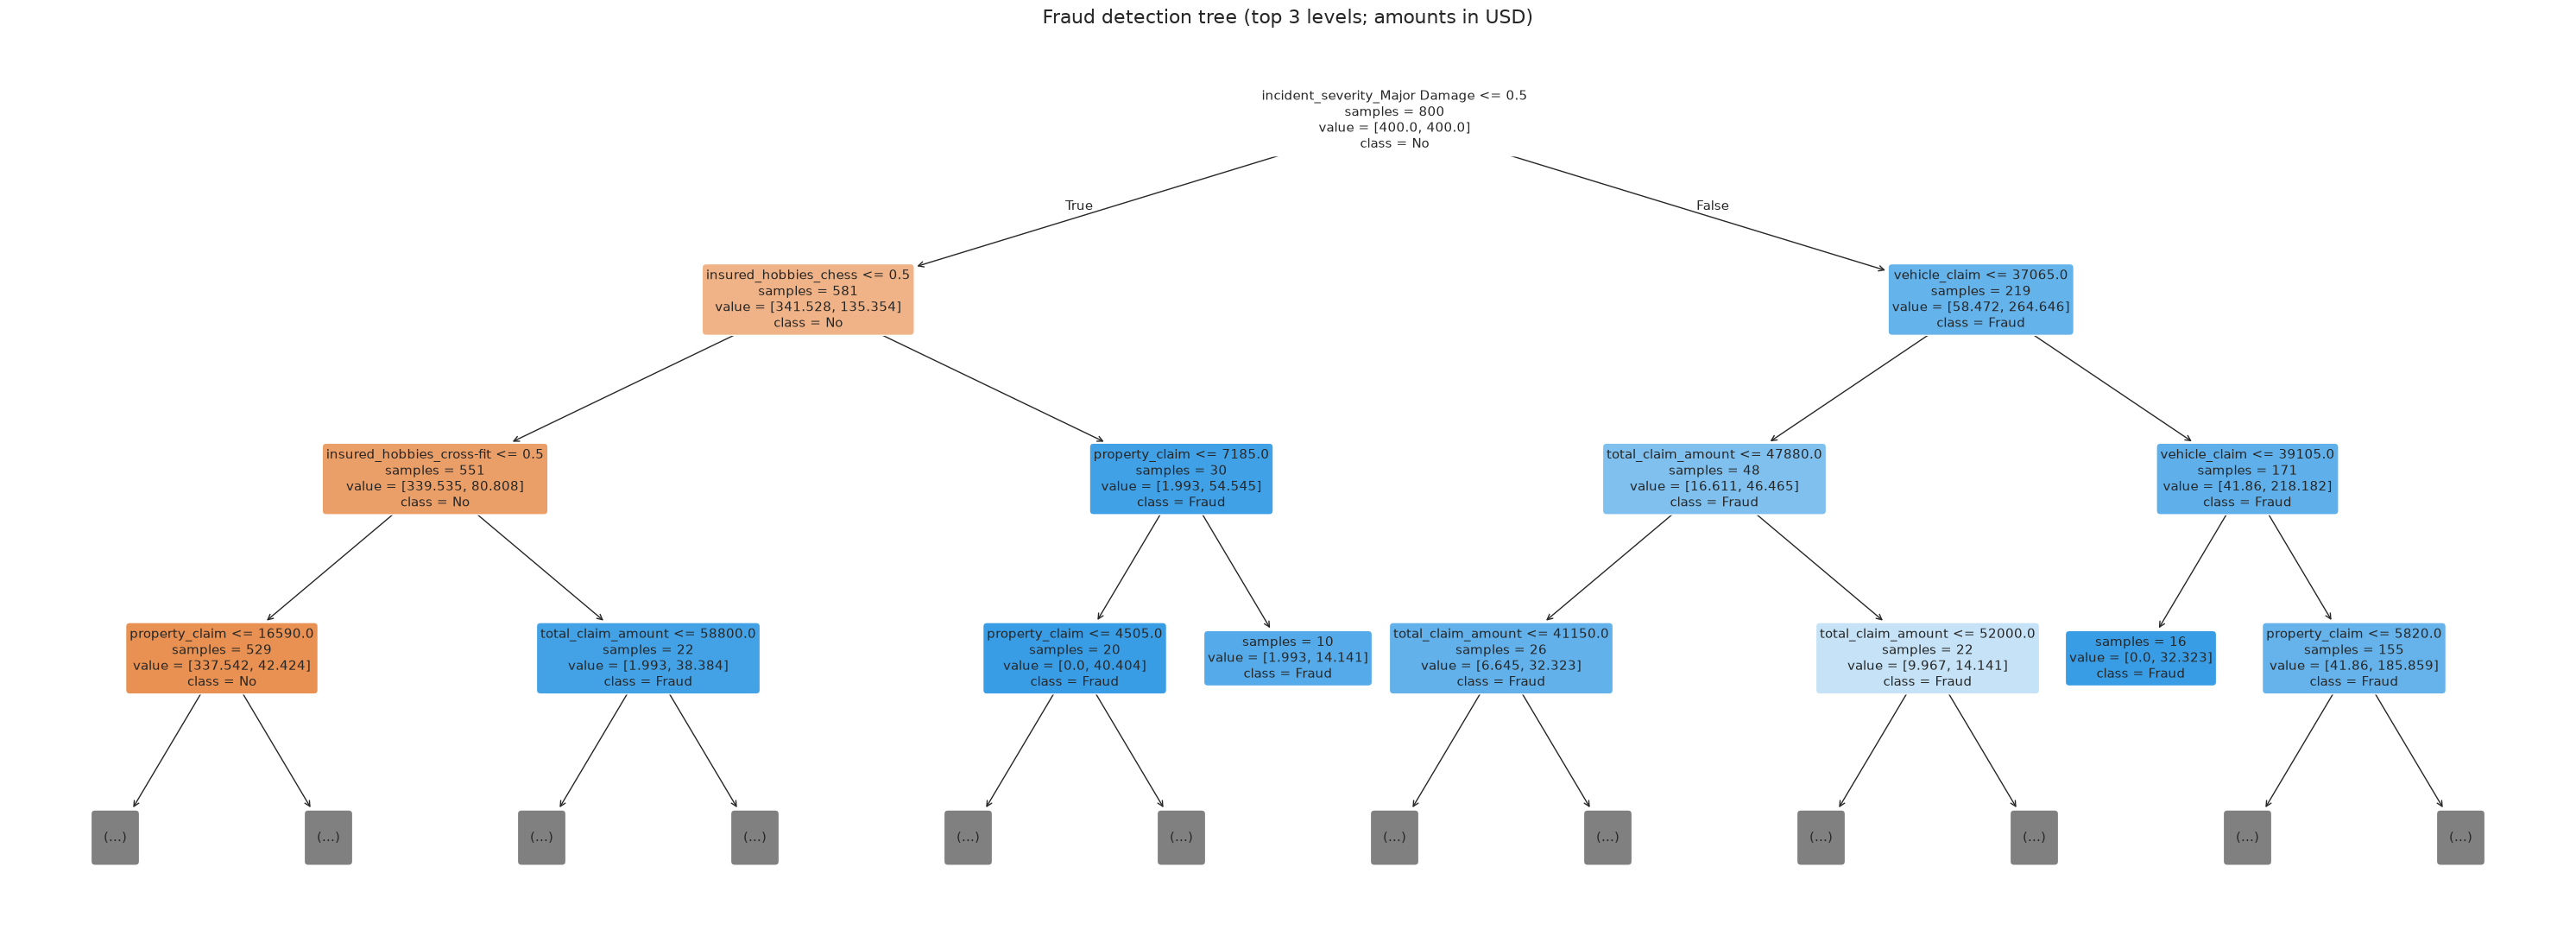

|--- incident_severity_Major Damage <= 0.50
|   |--- insured_hobbies_chess <= 0.50
|   |   |--- insured_hobbies_cross-fit <= 0.50
|   |   |   |--- property_claim <= 16590.00
|   |   |   |   |--- total_claim_amount <= 6140.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- total_claim_amount >  6140.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- property_claim >  16590.00
|   |   |   |   |--- class: 0
|   |   |--- insured_hobbies_cross-fit >  0.50
|   |   |   |--- total_claim_amount <= 58800.00
|   |   |   |   |--- class: 1
|   |   |   |--- total_claim_amount >  58800.00
|   |   |   |   |--- class: 1
|   |--- insured_hobbies_chess >  0.50
|   |   |--- property_claim <= 7185.00
|   |   |   |--- property_claim <= 4505.00
|   |   |   |   |--- class: 1
|   |   |   |--- property_claim >  4505.00
|   |   |   |   |--- class: 1
|   |   |--- property_claim >  7185.00
|   |   |   |--- class: 1
|--- incident_severity_Major Damage >  0.50
|   |--- vehicle_claim <= 37065.00
|   |   |--

In [28]:
dt_pipe = searches['Decision Tree'].best_estimator_
feat_after_pre = dt_pipe.named_steps['pre'].get_feature_names_out()
feat_dt = feat_after_pre[dt_pipe.named_steps['select'].get_support()]
feat_dt = [f.split('__', 1)[1] for f in feat_dt]
tree = dt_pipe.named_steps['model']
print('Params:', searches['Decision Tree'].best_params_, '| actual depth:', tree.get_depth(), '| leaves:', tree.get_n_leaves())

fig, ax = plt.subplots(figsize=(30, 11))
plot_tree(tree, feature_names=feat_dt, class_names=['No', 'Fraud'], filled=True, rounded=True,
          impurity=False, proportion=False, fontsize=11, ax=ax, max_depth=3)
ax.set_title('Fraud detection tree (top 3 levels; amounts in USD)', fontsize=16)
plt.tight_layout(); plt.savefig('figures/09_decision_tree.png', dpi=110); plt.show()
print(export_text(tree, feature_names=list(feat_dt), max_depth=4))

**How to read it:** each node is a question; the left branch (True) means the condition holds. For a one-hot feature (e.g. `incident_severity_Major Damage <= 0.5`), the left branch means **not** Major Damage. Orange nodes lean "not fraud", blue lean "fraud". `value` counts are weighted by `class_weight='balanced'`, so the root node shows both classes as balanced.

**Reading the tree:** the first split is always *is the damage severity Major Damage?* If not, the next split is *does the insured have chess or cross-fit as a hobby?* Deeper levels split only on claim amounts, and most of the leaves below still land on the same conclusion either way.

### 9.2 Top 5 most important features

In [29]:
# (a) Permutation importance on TEST with the final model (permuting each raw column before the pipeline)
perm = permutation_importance(final_model, X_test, y_test, scoring='average_precision',
                              n_repeats=30, random_state=SEED, n_jobs=-1)
perm_df = pd.DataFrame({'feature': X_test.columns, 'importance_mean': perm.importances_mean,
                        'importance_std': perm.importances_std}).sort_values('importance_mean', ascending=False)
perm_df.head(10).round(4)

,feature,importance_mean,importance_std
16,incident_severity,0.2143,0.0174
10,insured_hobbies,0.1248,0.0279
17,authorities_contacted,0.0111,0.0131
28,property_claim,0.0048,0.0143
15,collision_type,0.0041,0.0094
0,months_as_customer,0.0000,0.0000
5,policy_annual_premium,0.0000,0.0000
4,policy_deductable,0.0000,0.0000
3,policy_csl,0.0000,0.0000
2,policy_state,0.0000,0.0000


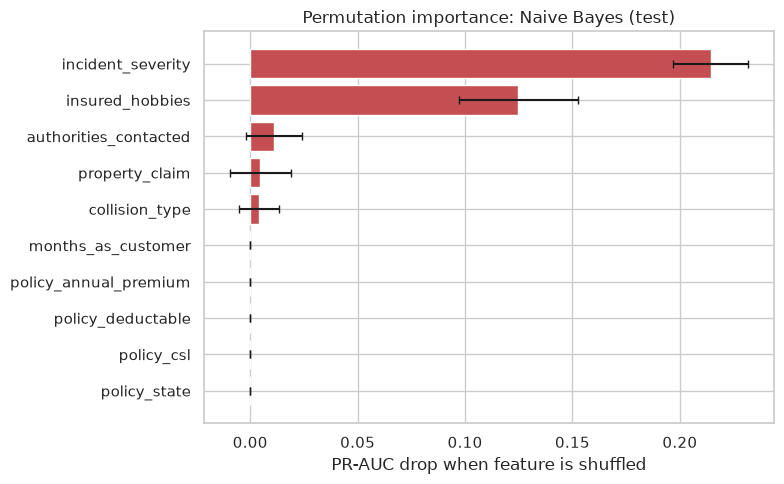

In [30]:
top = perm_df.head(10)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], color='#C44E52', capsize=3)
ax.set_xlabel('PR-AUC drop when feature is shuffled'); ax.set_title(f'Permutation importance: {best_name} (test)')
plt.tight_layout(); plt.savefig('figures/10_permutation_importance.png', dpi=120); plt.show()

In [31]:
# (b) Cross-check: Random Forest and Decision Tree's own importances, one-hot columns rolled back to raw
def grouped_importance(pipe, values):
    names = pipe.named_steps['pre'].get_feature_names_out()[pipe.named_steps['select'].get_support()]
    s = pd.Series(values, index=names)
    orig = {}
    for n in s.index:
        kind, rest = n.split('__', 1)
        base = rest if kind == 'num' else next(c for c in sorted(cat_cols, key=len, reverse=True) if rest.startswith(c + '_'))
        orig[n] = base
    return s.groupby(orig).sum().sort_values(ascending=False)

rf_pipe = searches['Random Forest'].best_estimator_
lr_pipe = searches['Logistic Regression'].best_estimator_
compare = pd.DataFrame({
    'Permutation (final model)': perm_df.set_index('feature')['importance_mean'].rank(ascending=False),
    'RF impurity': grouped_importance(rf_pipe, rf_pipe.named_steps['model'].feature_importances_).rank(ascending=False),
    'DT impurity': grouped_importance(dt_pipe, tree.feature_importances_).rank(ascending=False),
    '|LR coef|': grouped_importance(lr_pipe, np.abs(lr_pipe.named_steps['model'].coef_[0])).rank(ascending=False),
})
compare = compare.sort_values('Permutation (final model)').head(10)
compare

,Permutation (final model),RF impurity,DT impurity,|LR coef|
incident_severity,1.0,1.0,2.0,2.0
insured_hobbies,2.0,2.0,1.0,1.0
authorities_contacted,3.0,7.0,6.5,NaN
property_claim,4.0,5.0,4.0,NaN
collision_type,5.0,6.0,6.5,NaN
bodily_injuries,21.0,NaN,NaN,NaN
auto_model,21.0,NaN,NaN,NaN
auto_make,21.0,NaN,NaN,NaN
capital-loss,21.0,NaN,NaN,NaN
incident_city,21.0,NaN,NaN,NaN


In [32]:
# Consensus ranking: average rank across 4 methods (a feature the model never used gets the worst rank)
all_rank = pd.DataFrame({
    'Permutation (final model)': perm_df.set_index('feature')['importance_mean'].where(lambda s: s > 0),
    'RF impurity': grouped_importance(rf_pipe, rf_pipe.named_steps['model'].feature_importances_),
    'DT impurity': grouped_importance(dt_pipe, tree.feature_importances_).where(lambda s: s > 0),
    '|LR coef|': grouped_importance(lr_pipe, np.abs(lr_pipe.named_steps['model'].coef_[0])).where(lambda s: s > 0),
}).reindex(X_train.columns)
worst = len(all_rank)
ranks = all_rank.rank(ascending=False).fillna(worst)
ranks['mean_rank'] = ranks.mean(axis=1)
ranks = ranks.sort_values('mean_rank')
TOP5 = ranks.head(5).index.tolist()
print('Top 5 features (4-method consensus):', TOP5)
ranks.head(8).round(1)

Top 5 features (4-method consensus): ['insured_hobbies', 'incident_severity', 'vehicle_claim', 'property_claim', 'total_claim_amount']


,Permutation (final model),RF impurity,DT impurity,|LR coef|,mean_rank
insured_hobbies,2.0,2.0,1.0,1.0,1.5
incident_severity,1.0,1.0,2.0,2.0,1.5
vehicle_claim,38.0,3.0,5.0,3.0,12.2
property_claim,4.0,5.0,4.0,38.0,12.8
total_claim_amount,38.0,4.0,3.0,38.0,20.8
authorities_contacted,3.0,7.0,38.0,38.0,21.5
collision_type,5.0,6.0,38.0,38.0,21.8
months_as_customer,38.0,38.0,38.0,38.0,38.0


- `incident_severity` and `insured_hobbies` rank first under **every** method and account for nearly all the predictive power. Shuffling either one drops PR-AUC by 0.12-0.21.
- Ranks 3-5 (claim-amount features, `authorities_contacted`, etc.) have a small effect. For the final model, their importance is smaller than its own standard deviation, so the order among them is **unstable** and shouldn't be over-interpreted.

In [33]:
# Logistic Regression coefficients: direction of effect (odds ratio) for selected features
names = lr_pipe.named_steps['pre'].get_feature_names_out()[lr_pipe.named_steps['select'].get_support()]
coef = pd.Series(lr_pipe.named_steps['model'].coef_[0], index=[n.split('__', 1)[1] for n in names])
coef = coef[coef != 0].sort_values()
coef_df = pd.DataFrame({'coef': coef, 'odds_ratio': np.exp(coef)}).round(3)
coef_df.tail(8)

,coef,odds_ratio
incident_severity_Minor Damage,-0.180,0.835
vehicle_claim,0.035,1.036
incident_severity_Major Damage,3.290,26.843
insured_hobbies_cross-fit,4.450,85.655
insured_hobbies_chess,4.626,102.150


A positive coefficient (odds ratio > 1) means that feature raises the odds of fraud, holding the others fixed — a correlation in the data, not a causal claim.

### 9.3 Error analysis by segment (test)

In [34]:
err = X_test.assign(y=y_test.values, p=p_test, pred=(p_test >= best_thr).astype(int))
def grp(g):
    return pd.Series({'n': len(g), 'fraud_rate': g.y.mean(), 'recall': recall_score(g.y, g.pred, zero_division=0) if g.y.sum() else np.nan,
                      'precision': precision_score(g.y, g.pred, zero_division=0) if g.pred.sum() else np.nan,
                      'accuracy': (g.y == g.pred).mean()})
err.groupby('incident_severity').apply(grp).round(3)

,n,fraud_rate,recall,precision,accuracy
incident_severity,,,,,
Major Damage,57.0,0.632,1.000,0.632,0.632
Minor Damage,73.0,0.137,0.500,0.833,0.918
Total Loss,55.0,0.055,0.333,0.333,0.927
Trivial Damage,15.0,0.000,NaN,NaN,1.000


Check recall on fraud cases **outside** Major Damage — that's where the model would be missing cases, if anywhere, and is its main blind spot.

## 10. Conclusion & next steps

In [35]:
summary = {
    'best_model': best_name,
    'threshold': round(best_thr, 3),
    'test': final_eval.iloc[0].to_dict(),
    'baseline_test': final_eval.loc['Dummy baseline'].to_dict(),
    'cv_pr_auc_best': round(cv_best, 3),
    'top5': TOP5,
}
import json; print(json.dumps(summary, indent=2, ensure_ascii=False, default=float))

{
  "best_model": "Naive Bayes",
  "threshold": 0.372,
  "test": {
    "PR-AUC": 0.551,
    "ROC-AUC": 0.837,
    "F1": 0.73,
    "Precision": 0.636,
    "Recall": 0.857,
    "Accuracy": 0.845
  },
  "baseline_test": {
    "PR-AUC": 0.26,
    "ROC-AUC": 0.534,
    "F1": 0.3,
    "Precision": 0.294,
    "Recall": 0.306,
    "Accuracy": 0.65
  },
  "cv_pr_auc_best": 0.726,
  "top5": [
    "insured_hobbies",
    "incident_severity",
    "vehicle_claim",
    "property_claim",
    "total_claim_amount"
  ]
}


- Fraud signal concentrates in **damage severity (Major Damage)** and **insured hobbies (chess, cross-fit)**. A simple, shallow model already captures most of it.
- Aggressive feature selection doesn't hurt quality, and helps KNN/Naive Bayes noticeably.
- Next: check stability with repeated CV, get real (non-simulated) data, and weigh the actual business cost of false positives vs. false negatives when picking a threshold.